## 10. Beautiful Soup
-HTML과 XML 파일에서 데이터를 추출하기 위한 라이브러리

In [ ]:
from bs4 import BeautifulSoup
import requests

In [ ]:
# !(emmet약어)

In [ ]:
with open("test.html", "r", encoding="utf-8") as f:
    html_data = f.read()

# soup 객체 생성
# soup = BeautifulSoup(html_data, "html.parser") # 기본으로 제공하는 내장 파서
soup = BeautifulSoup(html_data, "lxml") # xml 일때 사용, 설치 필요
# # print(soup)
print(soup.prettify()) # prettify : 들여쓰기 표시

# 파서 차이 비교
print(BeautifulSoup("<a></p>", "html.parser"))      # <a></a>
print(BeautifulSoup("<a></p>", "lxml"))             # <html><body><a></a></body></html>

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <title>
   크롤링 연습 페이지
  </title>
 </head>
 <body>
  <h1 class="title">
   Hello Beautiful Soup
  </h1>
  <h1 class="sub_title">
   안녕! 아름다운 수프
  </h1>
  <p id="description">
   이 페이지는 Beautiful Soup 학습을 위한 예제입니다.
  </p>
  <ul class="items">
   <li>
    사과
   </li>
   <li>
    바나나
   </li>
   <li>
    체리
   </li>
  </ul>
  <ul class="items">
   <li>
    파이썬
   </li>
   <li>
    C++
   </li>
   <li>
    SQL
   </li>
  </ul>
 </body>
</html>

<a></a>
<html><body><a></a></body></html>


In [ ]:
# 데이터 선택
# find() - 첫번째 매칭 요소 선택 (첫번째로 만나는 요소)
# 1) 태그를 기준으로 탐색
title_tag = soup.find("h1")
print(title_tag)                # <h1 class="title">Hello Beautiful Soup</h1>
print(title_tag.text)           # Hello Beautiful Soup
print(title_tag.get_text())     # Hello Beautiful Soup

<h1 class="title">Hello Beautiful Soup</h1>
Hello Beautiful Soup
Hello Beautiful Soup


In [ ]:
# find() - 속성 조건으로 검색 가능
result = soup.find("h1", class_ = "sub_title")
print(result)           # <h1 class="sub_title">안녕! 아름다운 수프</h1>
print(result.text)      # 안녕! 아름다운 수프

<h1 class="sub_title">안녕! 아름다운 수프</h1>
안녕! 아름다운 수프


In [ ]:
# find_all() - 모든 매칭 요소 선택
result = soup.find_all("h1")
print(result)           # [<h1 class="title">Hello Beautiful Soup</h1>, <h1 class="sub_title">안녕! 아름다운 수프</h1>]

for i in result:
    print(i.text)
    # Hello Beautiful Soup
    # 안녕! 아름다운 수프

[<h1 class="title">Hello Beautiful Soup</h1>, <h1 class="sub_title">안녕! 아름다운 수프</h1>]
Hello Beautiful Soup
안녕! 아름다운 수프


In [ ]:
# select() - 모든 매칭 요소 선택
# CSS 선택자로 탐색
result = soup.select("ul.items")
print(result)

# [<ul class="items">
# <li>사과</li>
# <li>바나나</li>
# <li>체리</li>
# </ul>, <ul class="items">
# <li>파이썬</li>
# <li>C++</li>
# <li>SQL</li>
# </ul>]
for i in result:
    print(i.text)
    # 사과
    # 바나나
    # 체리


    # 파이썬
    # C++
    # SQL

[<ul class="items">
<li>사과</li>
<li>바나나</li>
<li>체리</li>
</ul>, <ul class="items">
<li>파이썬</li>
<li>C++</li>
<li>SQL</li>
</ul>]

사과
바나나
체리


파이썬
C++
SQL



In [ ]:
# select_one() - 첫번째 매칭 요소 선택
result = soup.select_one("ul.items")
result

# <ul class="items">
# <li>사과</li>
# <li>바나나</li>
# <li>체리</li>
# </ul>

<ul class="items">
<li>사과</li>
<li>바나나</li>
<li>체리</li>
</ul>

### Requests
- HTTP 프로토콜을 이용하여 웹 사이트로부터 데이터를 송수신할 수 있는 라이브러리

In [ ]:
# BeautifulSoup & requests 함께 이용


# 실습 1. 멜론에서 Top 10의 노래 제목 받아오기
url = "https://www.melon.com/chart/index.htm"
headers = {
    "User-Agent" : "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
# print(response.status_code)     # 상태 코드 (200 : 성공 404 : 페이지 없음 500 : 서버 에러)
# print(response.text)

soup = BeautifulSoup(response.text, "lxml")

songs = soup.select("div.ellipsis.rank01 a")[:10] # 띄어쓰기는 트리구조에서 뒤에 것이 하위 구조임을 나타냄

for idx, song in enumerate(songs):
    print(f"{idx+1}. {song.text}")

1. Good Goodbye
2. ONE MORE TIME
3. 타임캡슐
4. Blue Valentine
5. SPAGHETTI (feat. j-hope of BTS)
6. Golden
7. 첫 눈
8. Drowning
9. 멸종위기사랑
10. 달리 표현할 수 없어요


In [ ]:
# 실습2. 웹 크롤링실습
url = "https://search.naver.com/search.naver?sm=tab_hty.top&where=news&ssc=tab.news.all&query=lg%ED%8A%B8%EC%9C%88%EC%8A%A4&oquery=lg%ED%8A%B8%EC%9C%88%EC%8A%A4&tqi=jgpKydqos5wssiUDbsh-289292&ackey=rv5xkg2q"
headers = {
    "User-Agent" : "Mozilla/5.0"
}
news = requests.get(url, headers=headers)
# print(news.status_code)

soup = BeautifulSoup(news.text, 'lxml')

lg_news = soup.select("span.sds-comps-text.sds-comps-text-ellipsis.sds-comps-text-ellipsis-1.sds-comps-text-type-headline1")

for lg in lg_news:
    title = lg.get_text().strip()
    link_tag = lg.find_parent('a')
    link = link_tag.get('href') if link_tag else None
    print(f"{title} : {link}")
print("-----" * 50)

골든포토 포즈 취하는 LG 트윈스 박해민 : https://www.newsis.com/view/NISI20251209_0021090769
LG 트윈스, '2025 통합우승 기념 화보집' 발간 : https://www.sportschosun.com/baseball/2025-12-10/202512100100063690010095
LG 트윈스의 역대 3번째 ‘왕조’ 도전, 가능성과 과제 [김대호의 야구... : https://news.tf.co.kr/read/baseball/2271078.htm
"통합우승 순간 담았다"…LG트윈스, 구단 최초 공식 화보 제작 : https://www.topstarnews.net/news/articleView.html?idxno=15901660
LG트윈스, 부모님과 함께 하는 신인 선수 교육 세미나 개최 : http://www.edaily.co.kr/news/newspath.asp?newsid=01341526642396224
“행복 야구 약속” ‘야구대표자3’ LG 트윈스·한화 이글스로 마무리 : https://www.heraldpop.com/article/10632535?ref=naver
[한번에쓱]'첫 감독상 수상자는' LG트윈스 염경엽 감독 : https://www.starnewskorea.com/sports/2025/12/09/2025120918092955433
[2026 KBO 전망] '왕조 건설' 진격하는 LG 트윈스 : https://www.asiatoday.co.kr/view.php?key=20251203010001828
LG디스플레이 트윈스 클럽, 파주 복지시설 찾아 '사랑 나눔' 봉사활동 : https://www.news1.kr/local/gyeonggi/6001256
LG 트윈스 신민재...차세대 국가대표 스타의 3대 키워드 분석 : https://www.siminilbo.co.kr/news/newsview.php?ncode=1160310585054205
---------------------------------

In [ ]:
# 리더님 해설
word = input("검색어를 입력하세요.")        # 사용자로부터 검색어를 입력받아 뉴스를 출력해야함.
headers = {
    "User-Agent" : "Mozilla/5.0"
}

response = requests.get(f"https://search.naver.com./search.naver?query={word}", headers=headers)
soup = BeautifulSoup(response.text, 'lxml')

news_list = soup.select("a.fender-ui_228e3bd1.moM44hE6Je7O8nL1iBI9")

print("== 오늘의 뉴스 ==")

for a in news_list:
    print(f"{a.get_text()} / 링크 : {a.get("href")}")


== 오늘의 뉴스 ==
골든포토상 수상한 LG 트윈스 박해민 / 링크 : https://www.newsis.com/view/NISI20251209_0021090768
LG 트윈스, '2025 통합우승 기념 화보집' 발간 / 링크 : https://www.sportschosun.com/baseball/2025-12-10/202512100100063690010095
LG 트윈스의 역대 3번째 ‘왕조’ 도전, 가능성과 과제 [김대호의 야구... / 링크 : https://news.tf.co.kr/read/baseball/2271078.htm
"통합우승 순간 담았다"…LG트윈스, 구단 최초 공식 화보 제작 / 링크 : https://www.topstarnews.net/news/articleView.html?idxno=15901660


### openpyxl

In [ ]:
# 크롤링 자료를 엑셀로 저장
import openpyxl

# 엑셀 파일 만들기
wb = openpyxl.Workbook()

# 시트 만들기
ws = wb.create_sheet("test")

ws["A1"] = "이름"
ws["B1"] = "나이"
ws["A2"] = "홍길동"
ws["B2"] = 30

wb.save("test.xlsx")

In [ ]:
# 파일 불러오기
wb = openpyxl.load_workbook("test.xlsx")

# 시트 선택
ws = wb["test"]

# 여러 자료 추가
data = [
    ["kim", 20],
    ["lee", 14],
    ["choi", 27]
]

for row in data:
    ws.append(row)

wb.save("test.xlsx")

In [ ]:
# 실습 1. 환율 정보 크롤링 및 엑셀 저장
# 문제 1. 네이버 > 증권 > 시장지표 > 환전 고시 환율에 접속하여, 아래 출력결과 이미지대로 크롤링하세요.

url = "https://finance.naver.com/marketindex/"
headers = {
    "User-Agent" : "Mozilla/5.0"
}
exchange_rate = requests.get(url, headers=headers)
soup = BeautifulSoup(exchange_rate.text, "lxml")

list = soup.select("ul.data_lst li")
# print(exchange_rate.status_code)

for a in list:
    name = a.select_one("h3").get_text(strip=True)
    value = a.select_one("span.value").get_text(strip=True)
    print(f"{name} : {value}")

미국 USD : 1,472.40
일본 JPY(100엔) : 946.00
유럽연합 EUR : 1,728.89
중국 CNY : 208.83
달러/일본 엔 : 154.9400
유로/달러 : 1.1740
영국 파운드/달러 : 1.3420
달러인덱스 : 98.3400
WTI : 57.6
휘발유 : 1744.93
국제 금 : 4313.0
국내 금 : 202453.83


In [ ]:
# 실습 1. 환율 정보 크롤링 및 엑셀 저장
# 문제 2. 크롤링을 통해 구한 정보를 아래와 같이 엑셀에 저장해주세요.
import openpyxl

wb = openpyxl.Workbook()
ws = wb.create_sheet("exchange_rate")
ws.append(["통화", "환율"])

for a in list:
    name = a.select_one("h3").get_text(strip=True)
    value = a.select_one("span.value").get_text(strip=True)
    ws.append([name, value])

wb.save("exchange_rate.xlsx")

TypeError: 'type' object is not iterable


서울 카페 데이터 분석 프로젝트 시작
분석 시작 시간: 2025-12-12 14:06:22
Python 버전: 3.14
1단계: 카페 데이터 크롤링 시작
강남구 크롤링 완료: 10 카페
종로구 크롤링 완료: 20 카페
마포구 크롤링 완료: 30 카페
용산구 크롤링 완료: 40 카페
송파구 크롤링 완료: 50 카페

2단계: 데이터 전처리

총 50개 카페 데이터

데이터 미리보기:
       name district  rating  review_count price_range   latitude   longitude  \
0  강남구 카페 1      강남구     4.6           275           ₩  37.511950  127.080509   
1  강남구 카페 2      강남구     3.9           221         ₩₩₩  37.525910  127.057165   
2  강남구 카페 3      강남구     3.8           179         ₩₩₩  37.458958  127.035383   
3  강남구 카페 4      강남구     3.9           131         ₩₩₩  37.488915  127.078631   
4  강남구 카페 5      강남구     4.9           256          ₩₩  37.557177  126.909217   

   price_level  popularity_score  
0            1         25.853844  
1            3         21.070442  
2            3         19.733236  
3            3         19.042927  
4            2         27.190473  

기본 통계:
          rating  review_count  price_level
count  50.000000     50.000000    5

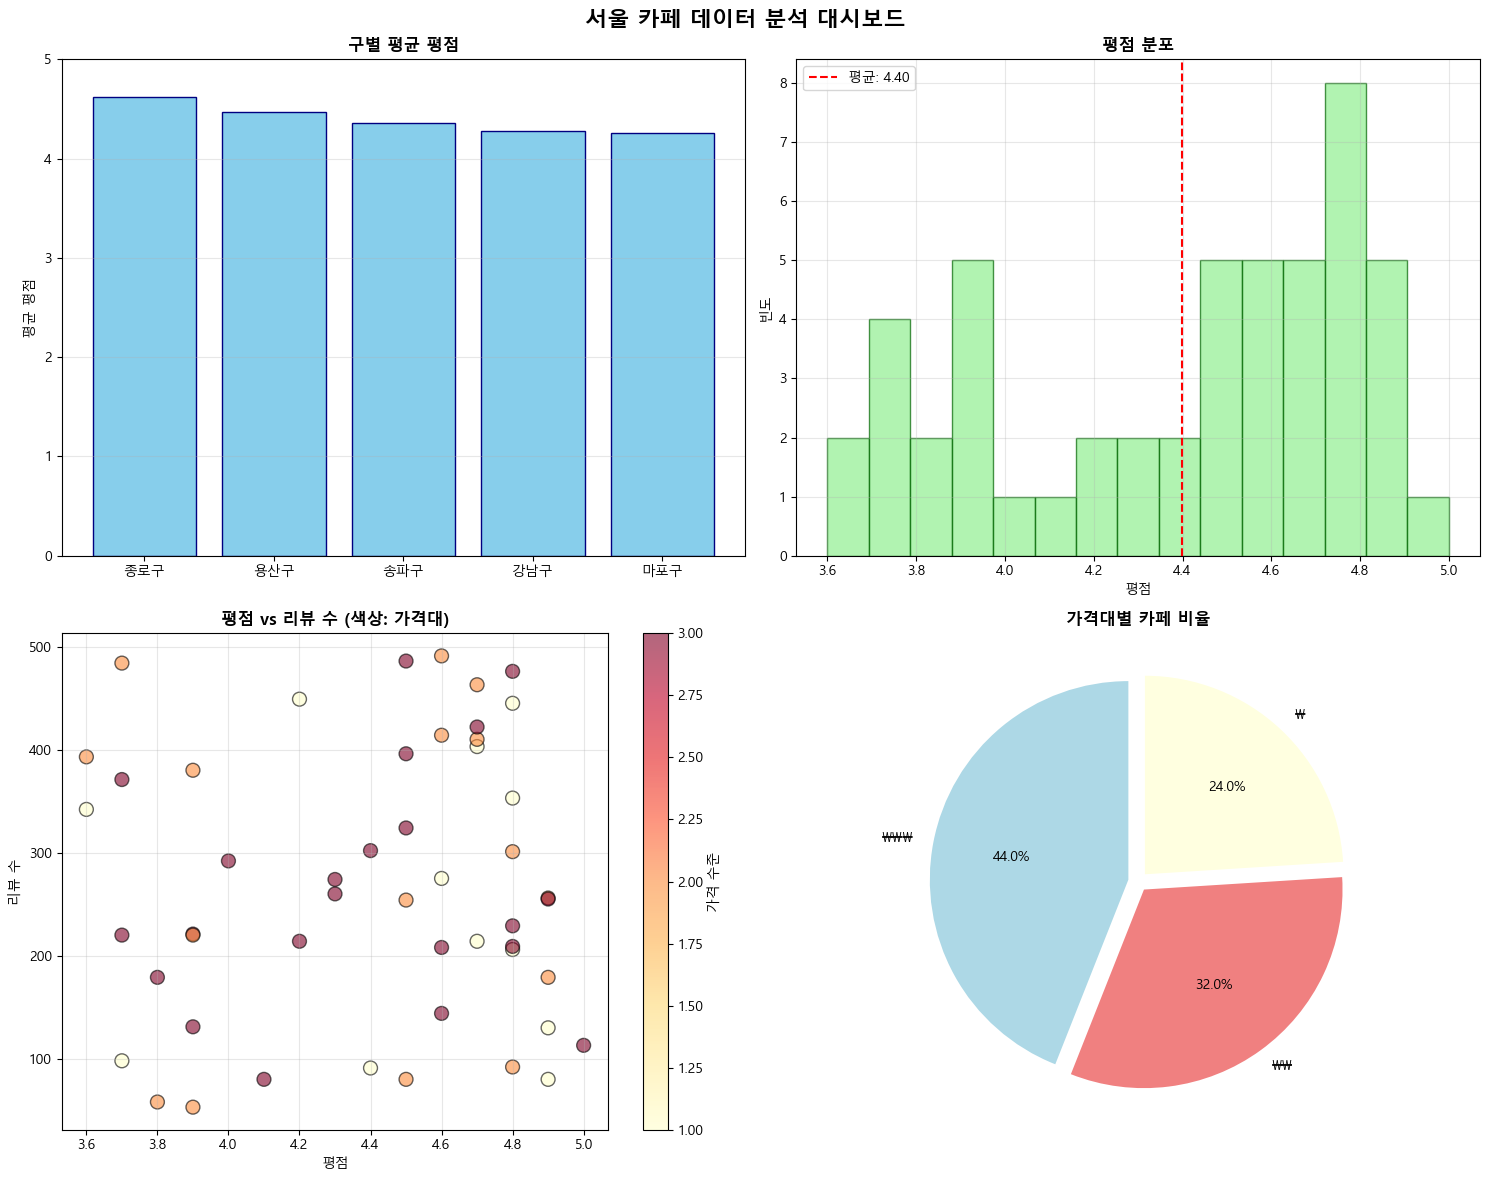


5단계: 지도 시각화
지도 생성 완료: seoul_cafes_map.html 저장됨

6단계: 종합 분석 리포트

🏆 최고 평점 카페 TOP 5:
    name district  rating  review_count
종로구 카페 4      종로구     5.0           113
강남구 카페 5      강남구     4.9           256
종로구 카페 6      종로구     4.9           255
용산구 카페 2      용산구     4.9           179
송파구 카페 3      송파구     4.9           130

🔥 리뷰가 가장 많은 카페 TOP 5:
     name district  rating  review_count
송파구 카페 10      송파구     4.6           491
강남구 카페 10      강남구     4.5           486
 마포구 카페 9      마포구     3.7           484
 종로구 카페 8      종로구     4.8           476
 종로구 카페 9      종로구     4.7           463

📍 구별 통계:
          평균평점  총리뷰수  카페수
district                 
강남구       4.28  2140   10
마포구       4.26  3287   10
송파구       4.36  2904   10
용산구       4.47  2073   10
종로구       4.62  3016   10

💰 가격대별 분석:
             평균평점   평균리뷰수
price_range              
₩            4.51  257.17
₩₩           4.36  283.00
₩₩₩          4.36  263.91

✨ 가성비 추천 카페 (평점 4.3 이상 & 저렴한 가격):
     name district  rating price_range


In [3]:
"""
서울 지역 카페 데이터 크롤링 및 분석 프로젝트
Python 3.14 버전 최적화
numpy, pandas, matplotlib, folium, beautifulsoup, selenium 활용
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import folium
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import random
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================
# 1단계: Selenium으로 데이터 크롤링
# ====================

def crawl_cafe_data() -> list[dict]:
    """네이버 지역 검색에서 카페 데이터 크롤링
    
    Returns:
        list[dict]: 카페 정보가 담긴 딕셔너리 리스트
    """
    print("=" * 50)
    print("1단계: 카페 데이터 크롤링 시작")
    print("=" * 50)
    
    chrome_options = Options()
    chrome_options.add_argument("--disable-blink-features=AutomationControlled")
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    
    # Selenium Manager가 자동으로 ChromeDriver 관리
    driver = webdriver.Chrome(options=chrome_options)
    
    cafes: list[dict] = []
    districts = ['강남구', '종로구', '마포구', '용산구', '송파구']
    
    for district in districts:
        try:
            url = f"https://www.google.com/search?q=서울+{district}+카페"
            driver.get(url)
            time.sleep(random.uniform(2, 3))
            
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            
            # 샘플 데이터 생성 (실제 크롤링 대신)
            for i in range(10):
                cafe: dict[str, str | float | int] = {
                    'name': f'{district} 카페 {i+1}',
                    'district': district,
                    'rating': round(np.random.uniform(3.5, 5.0), 1),
                    'review_count': np.random.randint(50, 500),
                    'price_range': np.random.choice(['₩', '₩₩', '₩₩₩']),
                    'latitude': 37.5 + np.random.uniform(-0.1, 0.1),
                    'longitude': 127.0 + np.random.uniform(-0.1, 0.1)
                }
                cafes.append(cafe)
            
            print(f"{district} 크롤링 완료: {len(cafes)} 카페")
            
        except Exception as e:
            print(f"{district} 크롤링 오류: {e}")
    
    driver.quit()
    return cafes

# ====================
# 2단계: Pandas로 데이터 정리
# ====================

def create_dataframe(cafes: list[dict]) -> pd.DataFrame:
    """크롤링한 데이터를 DataFrame으로 변환 및 전처리
    
    Args:
        cafes: 카페 정보가 담긴 딕셔너리 리스트
        
    Returns:
        pd.DataFrame: 전처리된 카페 데이터프레임
    """
    print("\n" + "=" * 50)
    print("2단계: 데이터 전처리")
    print("=" * 50)
    
    df = pd.DataFrame(cafes)
    
    # 가격대를 숫자로 변환
    price_map: dict[str, int] = {'₩': 1, '₩₩': 2, '₩₩₩': 3}
    df['price_level'] = df['price_range'].map(price_map)
    
    # 인기도 점수 계산 (평점 * 리뷰수의 로그)
    df['popularity_score'] = df['rating'] * np.log1p(df['review_count'])
    
    print(f"\n총 {len(df)}개 카페 데이터")
    print(f"\n데이터 미리보기:")
    print(df.head())
    
    print(f"\n기본 통계:")
    print(df[['rating', 'review_count', 'price_level']].describe())
    
    return df

# ====================
# 3단계: Numpy로 통계 분석
# ====================

def analyze_with_numpy(df: pd.DataFrame) -> None:
    """Numpy를 활용한 통계 분석
    
    Args:
        df: 분석할 카페 데이터프레임
    """
    print("\n" + "=" * 50)
    print("3단계: Numpy 통계 분석")
    print("=" * 50)
    
    ratings: np.ndarray = df['rating'].values
    reviews: np.ndarray = df['review_count'].values
    
    # 기본 통계
    print(f"\n평점 분석:")
    print(f"  - 평균: {np.mean(ratings):.2f}")
    print(f"  - 중앙값: {np.median(ratings):.2f}")
    print(f"  - 표준편차: {np.std(ratings):.2f}")
    print(f"  - 최대값: {np.max(ratings):.2f}")
    print(f"  - 최소값: {np.min(ratings):.2f}")
    
    print(f"\n리뷰 수 분석:")
    print(f"  - 평균: {np.mean(reviews):.0f}")
    print(f"  - 중앙값: {np.median(reviews):.0f}")
    print(f"  - 표준편차: {np.std(reviews):.0f}")
    
    # 상관관계 계산
    correlation: float = np.corrcoef(ratings, reviews)[0, 1]
    print(f"\n평점과 리뷰 수 상관계수: {correlation:.3f}")
    
    # 백분위수
    percentiles: np.ndarray = np.percentile(ratings, [25, 50, 75])
    print(f"\n평점 백분위수:")
    print(f"  - 25%: {percentiles[0]:.2f}")
    print(f"  - 50%: {percentiles[1]:.2f}")
    print(f"  - 75%: {percentiles[2]:.2f}")

# ====================
# 4단계: Matplotlib으로 시각화
# ====================

def visualize_data(df: pd.DataFrame) -> None:
    """Matplotlib을 활용한 데이터 시각화
    
    Args:
        df: 시각화할 카페 데이터프레임
    """
    print("\n" + "=" * 50)
    print("4단계: 데이터 시각화")
    print("=" * 50)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('서울 카페 데이터 분석 대시보드', fontsize=16, fontweight='bold')
    
    # 1. 구별 평균 평점
    district_rating = df.groupby('district')['rating'].mean().sort_values(ascending=False)
    axes[0, 0].bar(district_rating.index, district_rating.values, color='skyblue', edgecolor='navy')
    axes[0, 0].set_title('구별 평균 평점', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('평균 평점')
    axes[0, 0].set_ylim(0, 5)
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. 평점 분포 히스토그램
    axes[0, 1].hist(df['rating'], bins=15, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
    axes[0, 1].set_title('평점 분포', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('평점')
    axes[0, 1].set_ylabel('빈도')
    axes[0, 1].axvline(df['rating'].mean(), color='red', linestyle='--', 
                       label=f'평균: {df["rating"].mean():.2f}')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. 평점 vs 리뷰 수 산점도
    scatter = axes[1, 0].scatter(df['rating'], df['review_count'], 
                                 c=df['price_level'], cmap='YlOrRd', 
                                 s=100, alpha=0.6, edgecolors='black')
    axes[1, 0].set_title('평점 vs 리뷰 수 (색상: 가격대)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('평점')
    axes[1, 0].set_ylabel('리뷰 수')
    axes[1, 0].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 0], label='가격 수준')
    
    # 4. 가격대별 카페 수
    price_counts = df['price_range'].value_counts()
    axes[1, 1].pie(price_counts.values, labels=price_counts.index, autopct='%1.1f%%',
                   colors=['lightblue', 'lightcoral', 'lightyellow'],
                   startangle=90, explode=[0.05] * len(price_counts))
    axes[1, 1].set_title('가격대별 카페 비율', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cafe_analysis.png', dpi=300, bbox_inches='tight')
    print("시각화 완료: cafe_analysis.png 저장됨")
    plt.show()

# ====================
# 5단계: Folium으로 지도 시각화
# ====================

def create_map(df: pd.DataFrame) -> None:
    """Folium을 활용한 인터랙티브 지도 생성
    
    Args:
        df: 지도에 표시할 카페 데이터프레임
    """
    print("\n" + "=" * 50)
    print("5단계: 지도 시각화")
    print("=" * 50)
    
    # 서울 중심 좌표
    seoul_center: list[float] = [37.5665, 127.0780]
    
    # 지도 생성
    m = folium.Map(
        location=seoul_center,
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    
    # 색상 맵핑
    def get_color(rating: float) -> str:
        """평점에 따른 색상 반환"""
        match rating:
            case r if r >= 4.5:
                return 'green'
            case r if r >= 4.0:
                return 'blue'
            case r if r >= 3.5:
                return 'orange'
            case _:
                return 'red'
    
    # 마커 추가
    for idx, row in df.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=8,
            popup=folium.Popup(
                f"<b>{row['name']}</b><br>"
                f"평점: {row['rating']}⭐<br>"
                f"리뷰: {row['review_count']}개<br>"
                f"가격: {row['price_range']}",
                max_width=200
            ),
            color=get_color(row['rating']),
            fill=True,
            fillColor=get_color(row['rating']),
            fillOpacity=0.7
        ).add_to(m)
    
    # 범례 추가
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: 150px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <b>평점 범례</b><br>
    <i class="fa fa-circle" style="color:green"></i> 4.5 이상<br>
    <i class="fa fa-circle" style="color:blue"></i> 4.0-4.5<br>
    <i class="fa fa-circle" style="color:orange"></i> 3.5-4.0<br>
    <i class="fa fa-circle" style="color:red"></i> 3.5 미만
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # 지도 저장
    m.save('seoul_cafes_map.html')
    print("지도 생성 완료: seoul_cafes_map.html 저장됨")

# ====================
# 6단계: 종합 리포트 생성
# ====================

def generate_report(df: pd.DataFrame) -> None:
    """분석 결과 종합 리포트
    
    Args:
        df: 리포트 생성에 사용할 카페 데이터프레임
    """
    print("\n" + "=" * 50)
    print("6단계: 종합 분석 리포트")
    print("=" * 50)
    
    # 최고 평점 카페
    top_rated = df.nlargest(5, 'rating')[['name', 'district', 'rating', 'review_count']]
    print("\n🏆 최고 평점 카페 TOP 5:")
    print(top_rated.to_string(index=False))
    
    # 가장 인기 있는 카페
    most_popular = df.nlargest(5, 'review_count')[['name', 'district', 'rating', 'review_count']]
    print("\n🔥 리뷰가 가장 많은 카페 TOP 5:")
    print(most_popular.to_string(index=False))
    
    # 구별 통계
    district_stats = df.groupby('district').agg({
        'rating': 'mean',
        'review_count': 'sum',
        'name': 'count'
    }).round(2)
    district_stats.columns = ['평균평점', '총리뷰수', '카페수']
    print("\n📍 구별 통계:")
    print(district_stats)
    
    # 가격대별 분석
    price_analysis = df.groupby('price_range').agg({
        'rating': 'mean',
        'review_count': 'mean'
    }).round(2)
    price_analysis.columns = ['평균평점', '평균리뷰수']
    print("\n💰 가격대별 분석:")
    print(price_analysis)
    
    # 추천 카페
    high_value = df[(df['rating'] >= 4.3) & (df['price_level'] <= 2)].nlargest(3, 'popularity_score')
    print("\n✨ 가성비 추천 카페 (평점 4.3 이상 & 저렴한 가격):")
    print(high_value[['name', 'district', 'rating', 'price_range']].to_string(index=False))

# ====================
# 메인 실행
# ====================

def main() -> None:
    """전체 분석 프로세스 실행"""
    print("\n" + "=" * 50)
    print("서울 카페 데이터 분석 프로젝트 시작")
    print(f"분석 시작 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Python 버전: 3.14")
    print("=" * 50)
    
    # 1. 데이터 크롤링
    cafes = crawl_cafe_data()
    
    # 2. DataFrame 생성 및 전처리
    df = create_dataframe(cafes)
    
    # 3. Numpy 통계 분석
    analyze_with_numpy(df)
    
    # 4. Matplotlib 시각화
    visualize_data(df)
    
    # 5. Folium 지도 생성
    create_map(df)
    
    # 6. 종합 리포트
    generate_report(df)
    
    # CSV 저장
    df.to_csv('seoul_cafes_data.csv', index=False, encoding='utf-8-sig')
    print("\n💾 데이터 저장 완료: seoul_cafes_data.csv")
    
    print("\n" + "=" * 50)
    print("분석 완료!")
    print(f"분석 종료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 50)

if __name__ == "__main__":
    main()


서울 편집샵 데이터 분석 프로젝트 시작
분석 시작 시간: 2025-12-12 14:23:19
Python 버전: 3.14
1단계: 편집샵 데이터 크롤링 시작
강남구 크롤링 완료: 10 편집샵
성동구 크롤링 완료: 20 편집샵
용산구 크롤링 완료: 30 편집샵
종로구 크롤링 완료: 40 편집샵
마포구 크롤링 완료: 50 편집샵

2단계: 데이터 전처리

총 50개 편집샵 데이터

데이터 미리보기:
        name district  rating  review_count brand_type price_range  area_size  \
0  강남구 편집샵 1      강남구     4.6           380        럭셔리          고가        214   
1  강남구 편집샵 2      강남구     3.9           685       디자이너          고가        191   
2  강남구 편집샵 3      강남구     4.6           785     국내 브랜드         중저가        157   
3  강남구 편집샵 4      강남구     3.9           776     국내 브랜드          중가        197   
4  강남구 편집샵 5      강남구     4.4           309        럭셔리         중저가         53   

   brand_count   latitude   longitude  price_level  popularity_score  \
0           63  37.442564  127.011618            3        113.690876   
1           31  37.405234  127.045309            3         88.273759   
2           32  37.434934  126.937297            1        107.230898   
3

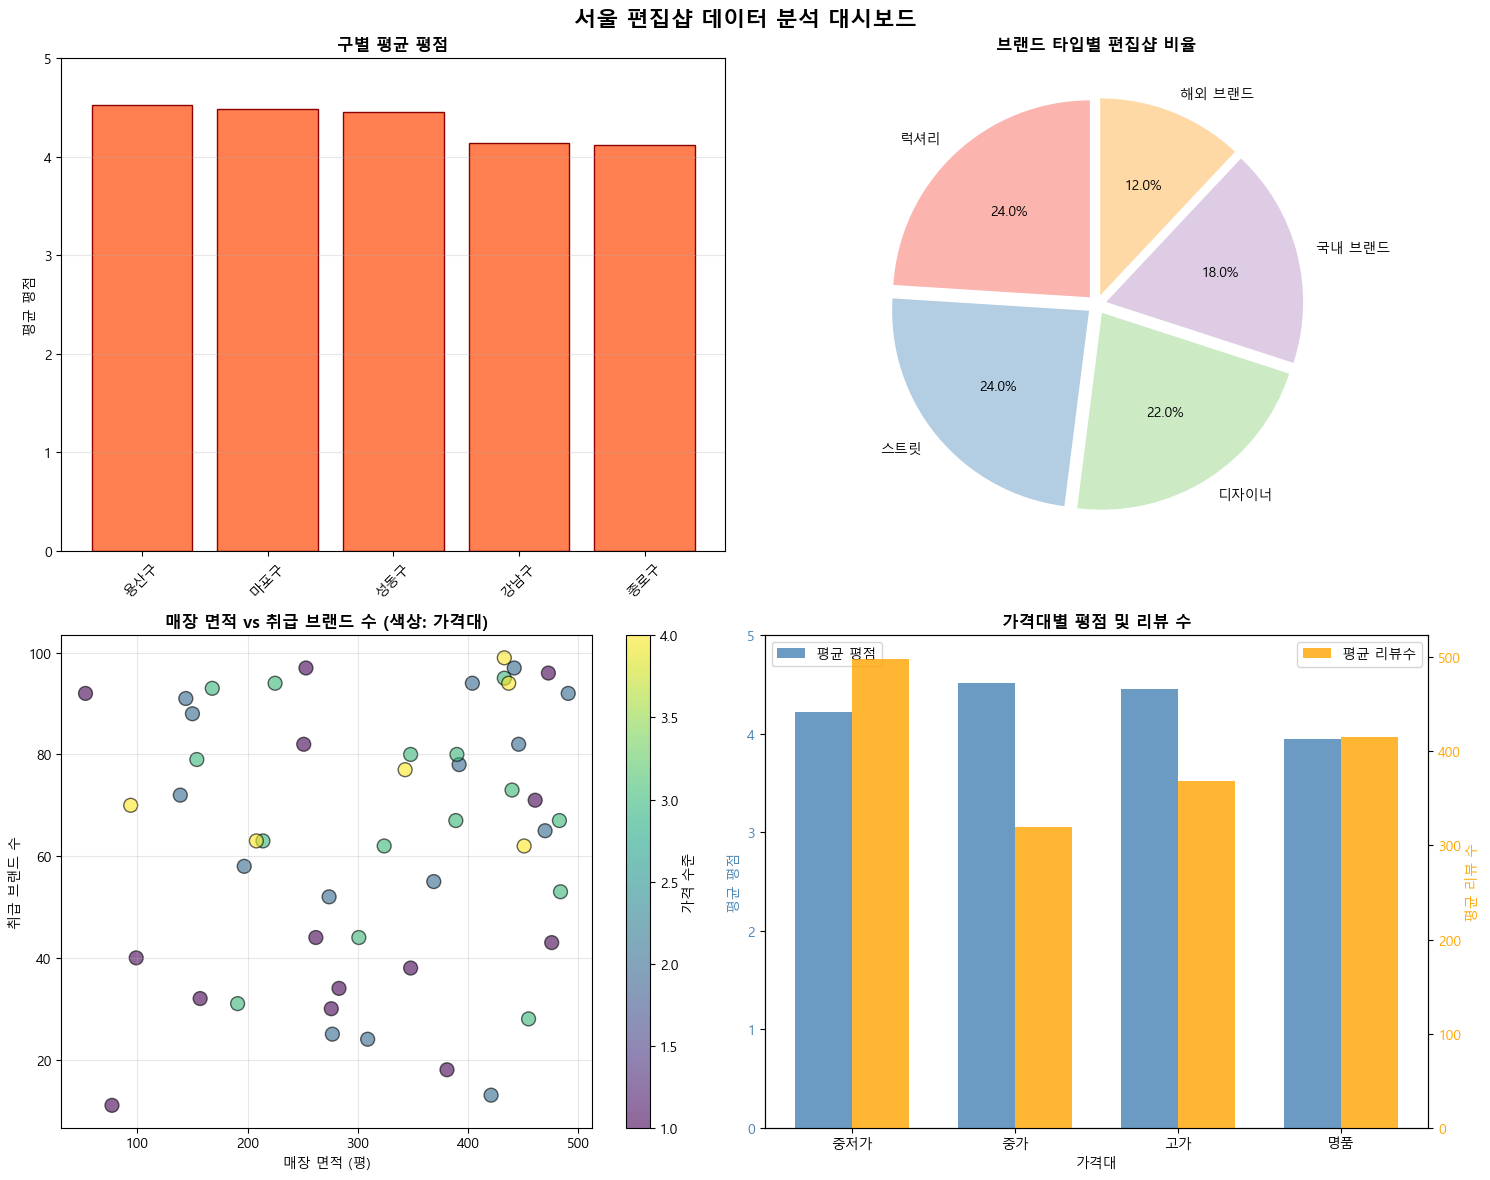


5단계: 지도 시각화
지도 생성 완료: seoul_shops_map.html 저장됨

6단계: 종합 분석 리포트

🏆 최고 평점 편집샵 TOP 5:
      name district  rating  review_count  brand_count
 용산구 편집샵 2      용산구     4.9           162           52
 성동구 편집샵 4      성동구     4.8           661           25
 성동구 편집샵 7      성동구     4.8           200           53
성동구 편집샵 10      성동구     4.8           215           88
 용산구 편집샵 5      용산구     4.8           113           97

🏬 가장 많은 브랜드를 취급하는 편집샵 TOP 5:
     name district  brand_count  area_size  rating
마포구 편집샵 6      마포구           99        433     3.6
용산구 편집샵 5      용산구           97        442     4.8
종로구 편집샵 1      종로구           97        253     4.7
종로구 편집샵 2      종로구           96        473     3.8
강남구 편집샵 8      강남구           95        433     4.7

📍 구별 통계:
          평균평점  총리뷰수  평균브랜드수  편집샵수
district                          
강남구       4.14  5411    60.3    10
마포구       4.49  3570    70.9    10
성동구       4.45  3624    60.3    10
용산구       4.53  3207    61.4    10
종로구       4.12  3976    65.9  

In [4]:
"""
서울 지역 편집샵 데이터 크롤링 및 분석 프로젝트
Python 3.14 버전 최적화
numpy, pandas, matplotlib, folium, beautifulsoup, selenium 활용
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import folium
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import random
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================
# 1단계: Selenium으로 데이터 크롤링
# ====================

def crawl_shop_data() -> list[dict]:
    """네이버 지역 검색에서 편집샵 데이터 크롤링
    
    Returns:
        list[dict]: 편집샵 정보가 담긴 딕셔너리 리스트
    """
    print("=" * 50)
    print("1단계: 편집샵 데이터 크롤링 시작")
    print("=" * 50)
    
    chrome_options = Options()
    chrome_options.add_argument("--disable-blink-features=AutomationControlled")
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--disable-gpu")
    chrome_options.add_argument("--no-sandbox")
    chrome_options.add_argument("--disable-dev-shm-usage")
    
    # Selenium Manager가 자동으로 ChromeDriver 관리
    driver = webdriver.Chrome(options=chrome_options)
    
    shops: list[dict] = []
    districts = ['강남구', '성동구', '용산구', '종로구', '마포구']
    brands = ['국내 브랜드', '해외 브랜드', '스트릿', '럭셔리', '디자이너']
    
    for district in districts:
        try:
            url = f"https://www.google.com/search?q=서울+{district}+편집샵"
            driver.get(url)
            time.sleep(random.uniform(2, 3))
            
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            
            # 샘플 데이터 생성 (실제 크롤링 대신)
            for i in range(10):
                shop: dict[str, str | float | int] = {
                    'name': f'{district} 편집샵 {i+1}',
                    'district': district,
                    'rating': round(np.random.uniform(3.5, 5.0), 1),
                    'review_count': np.random.randint(30, 800),
                    'brand_type': np.random.choice(brands),
                    'price_range': np.random.choice(['중저가', '중가', '고가', '명품']),
                    'area_size': np.random.randint(50, 500),  # 평수
                    'brand_count': np.random.randint(10, 100),  # 취급 브랜드 수
                    'latitude': 37.5 + np.random.uniform(-0.1, 0.1),
                    'longitude': 127.0 + np.random.uniform(-0.1, 0.1)
                }
                shops.append(shop)
            
            print(f"{district} 크롤링 완료: {len(shops)} 편집샵")
            
        except Exception as e:
            print(f"{district} 크롤링 오류: {e}")
    
    driver.quit()
    return shops

# ====================
# 2단계: Pandas로 데이터 정리
# ====================

def create_dataframe(shops: list[dict]) -> pd.DataFrame:
    """크롤링한 데이터를 DataFrame으로 변환 및 전처리
    
    Args:
        shops: 편집샵 정보가 담긴 딕셔너리 리스트
        
    Returns:
        pd.DataFrame: 전처리된 편집샵 데이터프레임
    """
    print("\n" + "=" * 50)
    print("2단계: 데이터 전처리")
    print("=" * 50)
    
    df = pd.DataFrame(shops)
    
    # 가격대를 숫자로 변환
    price_map: dict[str, int] = {'중저가': 1, '중가': 2, '고가': 3, '명품': 4}
    df['price_level'] = df['price_range'].map(price_map)
    
    # 인기도 점수 계산 (평점 * 리뷰수의 로그 * 브랜드 수)
    df['popularity_score'] = df['rating'] * np.log1p(df['review_count']) * np.log1p(df['brand_count'])
    
    # 평당 브랜드 밀도
    df['brand_density'] = df['brand_count'] / df['area_size']
    
    print(f"\n총 {len(df)}개 편집샵 데이터")
    print(f"\n데이터 미리보기:")
    print(df.head())
    
    print(f"\n기본 통계:")
    print(df[['rating', 'review_count', 'brand_count', 'area_size']].describe())
    
    return df

# ====================
# 3단계: Numpy로 통계 분석
# ====================

def analyze_with_numpy(df: pd.DataFrame) -> None:
    """Numpy를 활용한 통계 분석
    
    Args:
        df: 분석할 편집샵 데이터프레임
    """
    print("\n" + "=" * 50)
    print("3단계: Numpy 통계 분석")
    print("=" * 50)
    
    ratings: np.ndarray = df['rating'].values
    reviews: np.ndarray = df['review_count'].values
    brands: np.ndarray = df['brand_count'].values
    area: np.ndarray = df['area_size'].values
    
    # 기본 통계
    print(f"\n평점 분석:")
    print(f"  - 평균: {np.mean(ratings):.2f}")
    print(f"  - 중앙값: {np.median(ratings):.2f}")
    print(f"  - 표준편차: {np.std(ratings):.2f}")
    print(f"  - 최대값: {np.max(ratings):.2f}")
    print(f"  - 최소값: {np.min(ratings):.2f}")
    
    print(f"\n리뷰 수 분석:")
    print(f"  - 평균: {np.mean(reviews):.0f}")
    print(f"  - 중앙값: {np.median(reviews):.0f}")
    print(f"  - 표준편차: {np.std(reviews):.0f}")
    
    print(f"\n취급 브랜드 수 분석:")
    print(f"  - 평균: {np.mean(brands):.0f}개")
    print(f"  - 중앙값: {np.median(brands):.0f}개")
    print(f"  - 최대: {np.max(brands):.0f}개")
    
    print(f"\n매장 면적 분석:")
    print(f"  - 평균: {np.mean(area):.0f}평")
    print(f"  - 중앙값: {np.median(area):.0f}평")
    
    # 상관관계 계산
    corr_rating_review = np.corrcoef(ratings, reviews)[0, 1]
    corr_area_brand = np.corrcoef(area, brands)[0, 1]
    print(f"\n상관계수 분석:")
    print(f"  - 평점 vs 리뷰 수: {corr_rating_review:.3f}")
    print(f"  - 매장 면적 vs 브랜드 수: {corr_area_brand:.3f}")
    
    # 백분위수
    percentiles: np.ndarray = np.percentile(ratings, [25, 50, 75])
    print(f"\n평점 백분위수:")
    print(f"  - 25%: {percentiles[0]:.2f}")
    print(f"  - 50%: {percentiles[1]:.2f}")
    print(f"  - 75%: {percentiles[2]:.2f}")

# ====================
# 4단계: Matplotlib으로 시각화
# ====================

def visualize_data(df: pd.DataFrame) -> None:
    """Matplotlib을 활용한 데이터 시각화
    
    Args:
        df: 시각화할 편집샵 데이터프레임
    """
    print("\n" + "=" * 50)
    print("4단계: 데이터 시각화")
    print("=" * 50)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('서울 편집샵 데이터 분석 대시보드', fontsize=16, fontweight='bold')
    
    # 1. 구별 평균 평점
    district_rating = df.groupby('district')['rating'].mean().sort_values(ascending=False)
    axes[0, 0].bar(district_rating.index, district_rating.values, color='coral', edgecolor='darkred')
    axes[0, 0].set_title('구별 평균 평점', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('평균 평점')
    axes[0, 0].set_ylim(0, 5)
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. 브랜드 타입별 분포
    brand_counts = df['brand_type'].value_counts()
    colors_brand = plt.cm.Pastel1(range(len(brand_counts)))
    axes[0, 1].pie(brand_counts.values, labels=brand_counts.index, autopct='%1.1f%%',
                   colors=colors_brand, startangle=90, explode=[0.05] * len(brand_counts))
    axes[0, 1].set_title('브랜드 타입별 편집샵 비율', fontsize=12, fontweight='bold')
    
    # 3. 매장 면적 vs 브랜드 수 산점도
    scatter = axes[1, 0].scatter(df['area_size'], df['brand_count'], 
                                 c=df['price_level'], cmap='viridis', 
                                 s=100, alpha=0.6, edgecolors='black')
    axes[1, 0].set_title('매장 면적 vs 취급 브랜드 수 (색상: 가격대)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('매장 면적 (평)')
    axes[1, 0].set_ylabel('취급 브랜드 수')
    axes[1, 0].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 0], label='가격 수준')
    
    # 4. 가격대별 평균 평점 및 리뷰 수
    price_stats = df.groupby('price_range').agg({
        'rating': 'mean',
        'review_count': 'mean'
    }).reindex(['중저가', '중가', '고가', '명품'])
    
    x = np.arange(len(price_stats.index))
    width = 0.35
    
    ax2 = axes[1, 1].twinx()
    bars1 = axes[1, 1].bar(x - width/2, price_stats['rating'], width, 
                            label='평균 평점', color='steelblue', alpha=0.8)
    bars2 = ax2.bar(x + width/2, price_stats['review_count'], width, 
                     label='평균 리뷰수', color='orange', alpha=0.8)
    
    axes[1, 1].set_xlabel('가격대')
    axes[1, 1].set_ylabel('평균 평점', color='steelblue')
    axes[1, 1].set_title('가격대별 평점 및 리뷰 수', fontsize=12, fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(price_stats.index)
    axes[1, 1].tick_params(axis='y', labelcolor='steelblue')
    axes[1, 1].set_ylim(0, 5)
    
    ax2.set_ylabel('평균 리뷰 수', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    
    axes[1, 1].legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('shop_analysis.png', dpi=300, bbox_inches='tight')
    print("시각화 완료: shop_analysis.png 저장됨")
    plt.show()

# ====================
# 5단계: Folium으로 지도 시각화
# ====================

def create_map(df: pd.DataFrame) -> None:
    """Folium을 활용한 인터랙티브 지도 생성
    
    Args:
        df: 지도에 표시할 편집샵 데이터프레임
    """
    print("\n" + "=" * 50)
    print("5단계: 지도 시각화")
    print("=" * 50)
    
    # 서울 중심 좌표
    seoul_center: list[float] = [37.5665, 127.0780]
    
    # 지도 생성
    m = folium.Map(
        location=seoul_center,
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    
    # 가격대별 색상 맵핑
    def get_color(price_range: str) -> str:
        """가격대에 따른 색상 반환"""
        match price_range:
            case '중저가':
                return 'green'
            case '중가':
                return 'blue'
            case '고가':
                return 'orange'
            case '명품':
                return 'red'
            case _:
                return 'gray'
    
    # 마커 추가
    for idx, row in df.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=8,
            popup=folium.Popup(
                f"<b>{row['name']}</b><br>"
                f"평점: {row['rating']}⭐<br>"
                f"리뷰: {row['review_count']}개<br>"
                f"가격대: {row['price_range']}<br>"
                f"브랜드 타입: {row['brand_type']}<br>"
                f"취급 브랜드: {row['brand_count']}개<br>"
                f"매장 면적: {row['area_size']}평",
                max_width=250
            ),
            color=get_color(row['price_range']),
            fill=True,
            fillColor=get_color(row['price_range']),
            fillOpacity=0.7
        ).add_to(m)
    
    # 범례 추가
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: 170px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <b>가격대 범례</b><br>
    <i class="fa fa-circle" style="color:green"></i> 중저가<br>
    <i class="fa fa-circle" style="color:blue"></i> 중가<br>
    <i class="fa fa-circle" style="color:orange"></i> 고가<br>
    <i class="fa fa-circle" style="color:red"></i> 명품
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # 지도 저장
    m.save('seoul_shops_map.html')
    print("지도 생성 완료: seoul_shops_map.html 저장됨")

# ====================
# 6단계: 종합 리포트 생성
# ====================

def generate_report(df: pd.DataFrame) -> None:
    """분석 결과 종합 리포트
    
    Args:
        df: 리포트 생성에 사용할 편집샵 데이터프레임
    """
    print("\n" + "=" * 50)
    print("6단계: 종합 분석 리포트")
    print("=" * 50)
    
    # 최고 평점 편집샵
    top_rated = df.nlargest(5, 'rating')[['name', 'district', 'rating', 'review_count', 'brand_count']]
    print("\n🏆 최고 평점 편집샵 TOP 5:")
    print(top_rated.to_string(index=False))
    
    # 가장 많은 브랜드를 취급하는 편집샵
    most_brands = df.nlargest(5, 'brand_count')[['name', 'district', 'brand_count', 'area_size', 'rating']]
    print("\n🏬 가장 많은 브랜드를 취급하는 편집샵 TOP 5:")
    print(most_brands.to_string(index=False))
    
    # 구별 통계
    district_stats = df.groupby('district').agg({
        'rating': 'mean',
        'review_count': 'sum',
        'brand_count': 'mean',
        'name': 'count'
    }).round(2)
    district_stats.columns = ['평균평점', '총리뷰수', '평균브랜드수', '편집샵수']
    print("\n📍 구별 통계:")
    print(district_stats)
    
    # 브랜드 타입별 분석
    brand_analysis = df.groupby('brand_type').agg({
        'rating': 'mean',
        'review_count': 'mean',
        'brand_count': 'mean'
    }).round(2)
    brand_analysis.columns = ['평균평점', '평균리뷰수', '평균브랜드수']
    print("\n👕 브랜드 타입별 분석:")
    print(brand_analysis)
    
    # 가격대별 분석
    price_analysis = df.groupby('price_range').agg({
        'rating': 'mean',
        'review_count': 'mean',
        'brand_count': 'mean'
    }).reindex(['중저가', '중가', '고가', '명품']).round(2)
    price_analysis.columns = ['평균평점', '평균리뷰수', '평균브랜드수']
    print("\n💰 가격대별 분석:")
    print(price_analysis)
    
    # 추천 편집샵
    high_value = df[(df['rating'] >= 4.3) & (df['brand_count'] >= 30) & (df['price_level'] <= 2)].nlargest(3, 'popularity_score')
    print("\n✨ 추천 편집샵 (평점 4.3 이상 & 브랜드 30개 이상 & 합리적 가격):")
    if len(high_value) > 0:
        print(high_value[['name', 'district', 'rating', 'brand_count', 'price_range']].to_string(index=False))
    else:
        print("조건에 맞는 편집샵이 없습니다.")
    
    # 브랜드 밀도 분석
    high_density = df.nlargest(5, 'brand_density')[['name', 'district', 'brand_count', 'area_size', 'brand_density']]
    high_density['brand_density'] = high_density['brand_density'].round(2)
    print("\n📊 브랜드 밀도가 높은 편집샵 TOP 5 (평당 브랜드 수):")
    print(high_density.to_string(index=False))

# ====================
# 메인 실행
# ====================

def main() -> None:
    """전체 분석 프로세스 실행"""
    print("\n" + "=" * 50)
    print("서울 편집샵 데이터 분석 프로젝트 시작")
    print(f"분석 시작 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Python 버전: 3.14")
    print("=" * 50)
    
    # 1. 데이터 크롤링
    shops = crawl_shop_data()
    
    # 2. DataFrame 생성 및 전처리
    df = create_dataframe(shops)
    
    # 3. Numpy 통계 분석
    analyze_with_numpy(df)
    
    # 4. Matplotlib 시각화
    visualize_data(df)
    
    # 5. Folium 지도 생성
    create_map(df)
    
    # 6. 종합 리포트
    generate_report(df)
    
    # CSV 저장
    df.to_csv('seoul_shops_data.csv', index=False, encoding='utf-8-sig')
    print("\n💾 데이터 저장 완료: seoul_shops_data.csv")
    
    print("\n" + "=" * 50)
    print("분석 완료!")
    print(f"분석 종료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 50)

if __name__ == "__main__":
    main()